# TFM — Sistema de Apoyo a la Clasificación
## 02b: Análisis del Corpus Maestro Funcional (Post-Data Prep)
---
### Objetivo del Módulo
Validar la calidad del corpus maestro generado en `02_data_preparation.ipynb` **antes** de alimentar
cualquier modelo de Machine Learning. Este notebook documenta formalmente:
1. La magnitud de la compresión lograda (PRE vs POST).
2. El nuevo ratio de desbalance real entre clases únicas.
3. La distribución de artículos por supermercado.
4. La cobertura léxica y tokens más discriminantes por clase.
5. La decisión fundamentada sobre la estrategia anti-desbalance.

> **Justificación CRISP-DM:** Todo proceso riguroso exige verificar la calidad del dataset transformado
> *antes* de proceder al modelado. Sin esta validación, cualquier resultado posterior carece de fundamento documental.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# === Configuración visual ===
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})
COLOR_P = '#2ecc71'   # Verde - PERMITIDO
COLOR_NP = '#e74c3c'  # Rojo - NO PERMITIDO

# === CARGA ===
from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/Colab Notebooks/TFM - Master en IA y Ciencia de Datos'

df_raw = pd.read_csv(f'{BASE}/data/raw/Dataset.csv', sep=';', dtype={'COD_EAN': str}, low_memory=False)
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TFM - Master en IA y Ciencia de Datos/data/processed/diccionario_maestro.csv', sep=';')

print(f'\U0001F539 Dataset original:  {df_raw.shape[0]:>10,} filas x {df_raw.shape[1]} cols')
print(f'\U0001F539 Corpus maestro:    {df.shape[0]:>10,} filas x {df.shape[1]} cols')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔹 Dataset original:     659,272 filas x 17 cols
🔹 Corpus maestro:        38,694 filas x 4 cols


## 1. Tabla Comparativa PRE vs POST Limpieza
Cuantificamos el impacto exacto de la des-duplicación y el aislamiento de conflictos.

In [6]:
# === Métricas PRE ===
n_pre = len(df_raw)
n_p_pre = (df_raw['ESTADO'].astype(str).str.upper().str.strip() == 'PERMITIDO').sum()
n_np_pre = (df_raw['ESTADO'].astype(str).str.upper().str.strip() == 'NO PERMITIDO').sum()
ratio_pre = n_p_pre / max(n_np_pre, 1)

# === Métricas POST ===
n_post = len(df)
n_p_post = (df['ESTADO'] == 'PERMITIDO').sum()
n_np_post = (df['ESTADO'] == 'NO PERMITIDO').sum()
ratio_post = n_p_post / max(n_np_post, 1)
reduccion = (1 - n_post / n_pre) * 100

# === Tabla resumen ===
resumen = pd.DataFrame({
    'Métrica': ['Total filas', 'PERMITIDO', 'NO PERMITIDO', 'Ratio desbalance', '% Reducción'],
    'PRE (Dataset.csv)': [f'{n_pre:,}', f'{n_p_pre:,}', f'{n_np_pre:,}', f'{ratio_pre:.0f}:1', '—'],
    'POST (Maestro)': [f'{n_post:,}', f'{n_p_post:,}', f'{n_np_post:,}', f'{ratio_post:.0f}:1', f'{reduccion:.1f}%']
})
display(resumen.style.set_caption('Impacto de la Des-duplicación Conservadora').hide(axis='index'))

print(f'\n\U0001F4CA Conclusión: Se redujo un {reduccion:.1f}% del volumen manteniendo {n_np_post:,} entidades NO PERMITIDO únicas.')
print(f'    El ratio de desbalance mejoró de {ratio_pre:.0f}:1 a {ratio_post:.0f}:1.')

Métrica,PRE (Dataset.csv),POST (Maestro)
Total filas,"659,272","38,694"
PERMITIDO,"656,576","37,863"
NO PERMITIDO,"2,696",831
Ratio desbalance,244:1,46:1
% Reducción,—,94.1%



📊 Conclusión: Se redujo un 94.1% del volumen manteniendo 831 entidades NO PERMITIDO únicas.
    El ratio de desbalance mejoró de 244:1 a 46:1.


## 2. Distribución de Clases en el Corpus Maestro
Visualización del desbalance real con el que se entrenará el modelo.

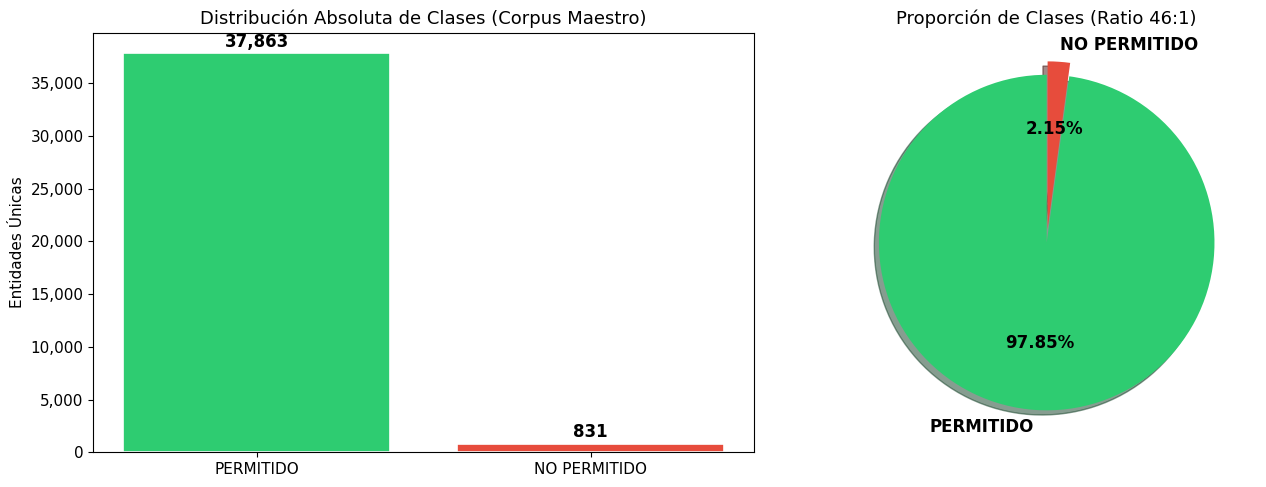

⚠️  Ratio 46:1 — Desbalance EXTREMO. Se requiere class_weight="balanced" como mínimo.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras absolutas
counts = df['ESTADO'].value_counts()
colors = [COLOR_P if x == 'PERMITIDO' else COLOR_NP for x in counts.index]
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Distribución Absoluta de Clases (Corpus Maestro)')
axes[0].set_ylabel('Entidades Únicas')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors, autopct='%1.2f%%',
            startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'},
            explode=[0, 0.08], shadow=True)
axes[1].set_title(f'Proporción de Clases (Ratio {ratio_post:.0f}:1)')

plt.tight_layout()
plt.savefig('/content/dist_clases_maestro.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\u26A0\uFE0F  Ratio {ratio_post:.0f}:1 — Desbalance EXTREMO. Se requiere class_weight="balanced" como mínimo.')

## 3. Distribución por Supermercado (`NOMBRE_EMPRESA`)
Verificamos que la des-duplicación fue equitativa y no sesgó hacia un proveedor.

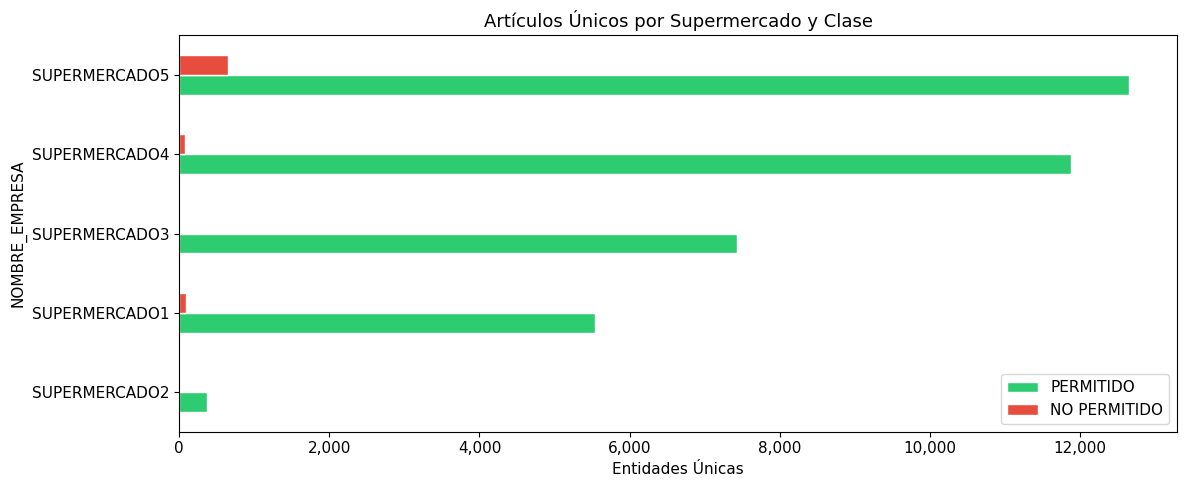

ESTADO,NO PERMITIDO,PERMITIDO,TOTAL,% NP
NOMBRE_EMPRESA,,,,
SUPERMERCADO5,648,12656,13304,4.87
SUPERMERCADO4,81,11871,11952,0.68
SUPERMERCADO3,3,7423,7426,0.04
SUPERMERCADO1,91,5544,5635,1.61
SUPERMERCADO2,8,369,377,2.12


In [8]:
# Conteo por empresa y estado
dist_empresa = df.groupby(['NOMBRE_EMPRESA', 'ESTADO']).size().unstack(fill_value=0)
dist_empresa = dist_empresa.sort_values('PERMITIDO', ascending=True)

fig, ax = plt.subplots(figsize=(12, max(5, len(dist_empresa) * 0.6)))
cols_plot = [c for c in ['PERMITIDO', 'NO PERMITIDO'] if c in dist_empresa.columns]
bar_colors = [COLOR_P, COLOR_NP][:len(cols_plot)]
dist_empresa[cols_plot].plot(kind='barh', stacked=False, ax=ax, color=bar_colors, edgecolor='white')
ax.set_title('Artículos Únicos por Supermercado y Clase')
ax.set_xlabel('Entidades Únicas')
ax.legend(loc='lower right')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('/content/dist_empresa_maestro.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla numérica
dist_empresa['TOTAL'] = dist_empresa.sum(axis=1)
if 'NO PERMITIDO' in dist_empresa.columns:
    dist_empresa['% NP'] = (dist_empresa['NO PERMITIDO'] / dist_empresa['TOTAL'] * 100).round(2)
display(dist_empresa.sort_values('TOTAL', ascending=False))

## 4. Análisis de Longitud Textual del Corpus Maestro
Verificamos que la des-duplicación no alteró significativamente la distribución de longitudes.

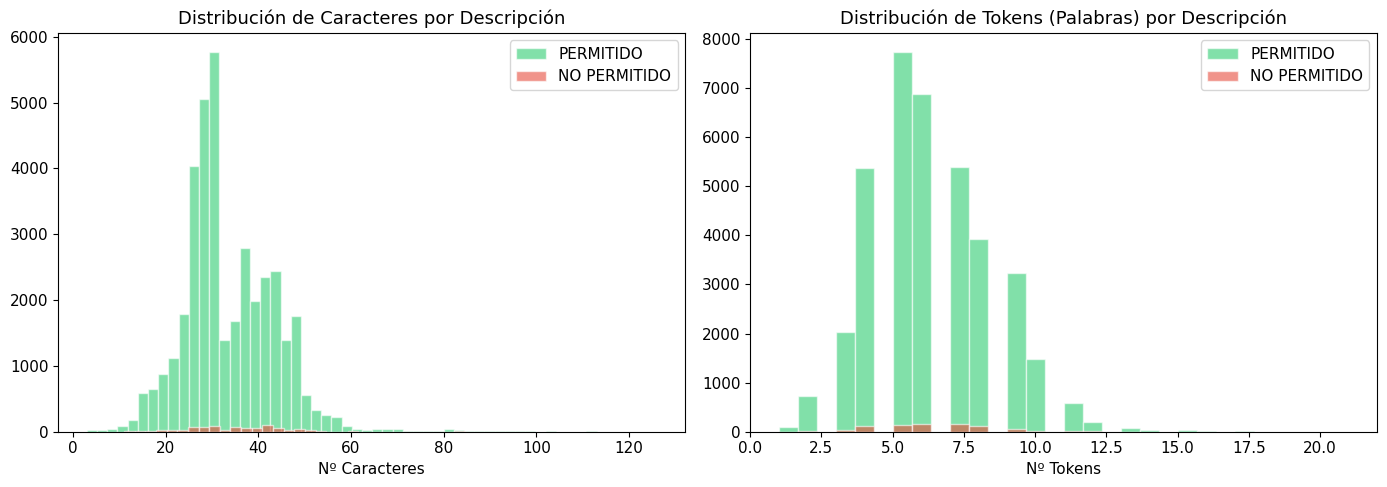

_n_chars                                            _n_tokens  \
                count  mean   std   min   25%   50%   75%    max     count   
ESTADO                                                                       
NO PERMITIDO    831.0  36.4  11.6  11.0  29.0  36.0  43.0  126.0     831.0   
PERMITIDO     37863.0  33.6  10.0   3.0  28.0  30.0  41.0  113.0   37863.0   

                                                  
             mean  std  min  25%  50%  75%   max  
ESTADO                                            
NO PERMITIDO  6.3  2.3  1.0  5.0  6.0  8.0  21.0  
PERMITIDO     6.2  2.1  1.0  5.0  6.0  8.0  21.0

In [9]:
df['_n_chars'] = df['DESCRIPCION_ARTICULO'].astype(str).str.len()
df['_n_tokens'] = df['DESCRIPCION_ARTICULO'].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for estado, color in [('PERMITIDO', COLOR_P), ('NO PERMITIDO', COLOR_NP)]:
    subset = df[df['ESTADO'] == estado]
    axes[0].hist(subset['_n_chars'], bins=50, alpha=0.6, color=color, label=estado, edgecolor='white')
    axes[1].hist(subset['_n_tokens'], bins=30, alpha=0.6, color=color, label=estado, edgecolor='white')

axes[0].set_title('Distribución de Caracteres por Descripción')
axes[0].set_xlabel('Nº Caracteres')
axes[0].legend()
axes[1].set_title('Distribución de Tokens (Palabras) por Descripción')
axes[1].set_xlabel('Nº Tokens')
axes[1].legend()
plt.tight_layout()
plt.savefig('/content/longitud_textual_maestro.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadísticas
stats = df.groupby('ESTADO')[['_n_chars', '_n_tokens']].describe().round(1)
display(stats)

## 5. Top Tokens Discriminantes por Clase
Verificamos que existe señal léxica suficiente para que TF-IDF sea efectivo.

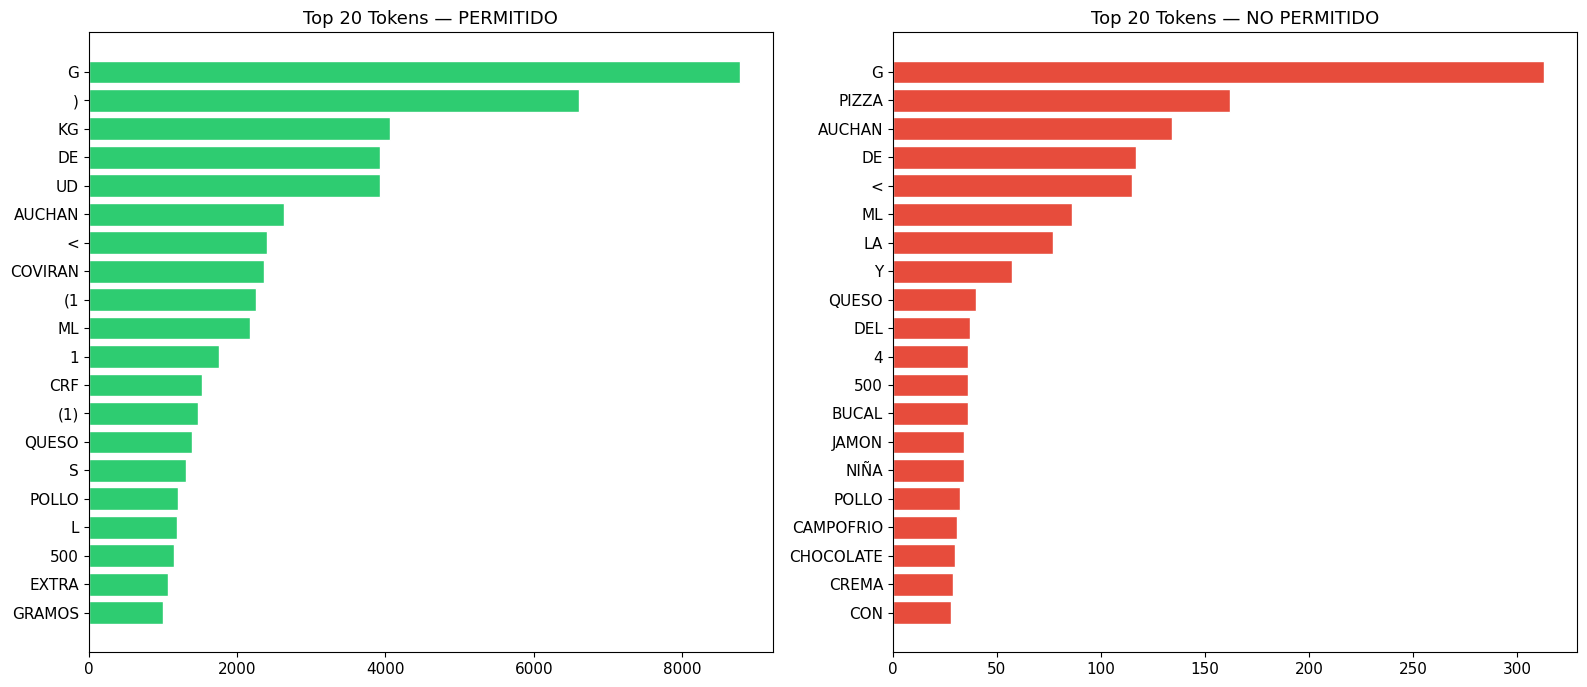


🔍 Tokens exclusivos de NO PERMITIDO (no aparecen en top-200 de PERMITIDO):
   ['&', '-', '120', '125G', '135G', '160', '180', '205', '330', '350G', '360', '410', '50G', '60', '80', '90G', 'ACCION', 'AGUA', 'AIR', 'ALCAMPO', 'ALCOHOL', 'ASTURIANO', 'BACON', 'BARBACOA', 'BOCADITOS', 'BOLLERIA', 'BOLOÑESA', 'BUCAL', 'BUENO', 'BUITONI']


In [10]:
def get_top_tokens(dataframe, estado, top_n=20):
    textos = dataframe[dataframe['ESTADO'] == estado]['DESCRIPCION_ARTICULO'].astype(str)
    all_tokens = ' '.join(textos).split()
    return Counter(all_tokens).most_common(top_n)

top_p = get_top_tokens(df, 'PERMITIDO', 20)
top_np = get_top_tokens(df, 'NO PERMITIDO', 20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# PERMITIDO
words_p, counts_p = zip(*reversed(top_p))
axes[0].barh(words_p, counts_p, color=COLOR_P, edgecolor='white')
axes[0].set_title('Top 20 Tokens — PERMITIDO')

# NO PERMITIDO
words_np, counts_np = zip(*reversed(top_np))
axes[1].barh(words_np, counts_np, color=COLOR_NP, edgecolor='white')
axes[1].set_title('Top 20 Tokens — NO PERMITIDO')

plt.tight_layout()
plt.savefig('/content/top_tokens_maestro.png', dpi=150, bbox_inches='tight')
plt.show()

# Tokens exclusivos de NO PERMITIDO
set_p = set(w for w, _ in get_top_tokens(df, 'PERMITIDO', 200))
set_np = set(w for w, _ in get_top_tokens(df, 'NO PERMITIDO', 200))
exclusivos_np = set_np - set_p
print(f'\n\U0001F50D Tokens exclusivos de NO PERMITIDO (no aparecen en top-200 de PERMITIDO):')
print(f'   {sorted(exclusivos_np)[:30]}')

## 6. Cobertura Léxica (Vocabulario Único)
Métricas clave para dimensionar el vectorizador TF-IDF.

In [11]:
vocab_total = set(' '.join(df['DESCRIPCION_ARTICULO'].astype(str)).split())
vocab_p = set(' '.join(df[df['ESTADO']=='PERMITIDO']['DESCRIPCION_ARTICULO'].astype(str)).split())
vocab_np = set(' '.join(df[df['ESTADO']=='NO PERMITIDO']['DESCRIPCION_ARTICULO'].astype(str)).split())

print(f'=== COBERTURA LÉXICA DEL CORPUS MAESTRO ===')
print(f'   Vocabulario total (tokens únicos):    {len(vocab_total):,}')
print(f'   Vocabulario PERMITIDO:                {len(vocab_p):,}')
print(f'   Vocabulario NO PERMITIDO:             {len(vocab_np):,}')
print(f'   Tokens compartidos:                   {len(vocab_p & vocab_np):,}')
print(f'   Tokens exclusivos de NP:              {len(vocab_np - vocab_p):,}')
print(f'   Descripciones únicas totales:         {df["DESCRIPCION_ARTICULO"].nunique():,}')
print(f'\n   Solapamiento léxico: {len(vocab_p & vocab_np)/len(vocab_np)*100:.1f}% del vocabulario NP también aparece en P.')
print(f'   \u2192 Esto confirma que la clasificación NO es trivial por palabras sueltas; se necesita contexto n-grama.')

=== COBERTURA LÉXICA DEL CORPUS MAESTRO ===
   Vocabulario total (tokens únicos):    16,710
   Vocabulario PERMITIDO:                16,347
   Vocabulario NO PERMITIDO:             1,450
   Tokens compartidos:                   1,087
   Tokens exclusivos de NP:              363
   Descripciones únicas totales:         38,536

   Solapamiento léxico: 75.0% del vocabulario NP también aparece en P.
   → Esto confirma que la clasificación NO es trivial por palabras sueltas; se necesita contexto n-grama.


## 7. Conclusión y Decisión de Estrategia Anti-Desbalance

### Hallazgos Clave
1. **Compresión efectiva:** La des-duplicación redujo drásticamente el volumen sin perder entidades de la clase minoritaria.
2. **Desbalance persistente:** El ratio sigue siendo extremo, confirmando la necesidad de técnicas compensatorias.
3. **Señal léxica existente:** Hay tokens discriminantes claros en NO PERMITIDO, lo que valida el enfoque TF-IDF.

### Decisión Fundamentada
Dado el ratio de desbalance post-limpieza:
- **Primera línea:** `class_weight='balanced'` en el clasificador lineal.
- **Evaluación:** Si el Recall de NO PERMITIDO cae por debajo del 80%, se evaluará oversampling (SMOTE) o ajuste de umbrales de decisión.
- **Métrica principal:** PR-AUC y F1-Score de la clase minoritaria.

> **Siguiente paso:** `notebooks/03_modeling.ipynb` — Fase 2 (Motor Léxico-Morfológico)

In [12]:
# Limpieza de columnas auxiliares
df = df.drop(columns=[c for c in df.columns if c.startswith('_')], errors='ignore')
print('\u2705 Análisis Post-Data Prep completado.')
print(f'   Corpus maestro listo para modelado: {len(df):,} entidades únicas.')
print(f'   \U0001F449 Siguiente paso: notebooks/03_modeling.ipynb')

✅ Análisis Post-Data Prep completado.
   Corpus maestro listo para modelado: 38,694 entidades únicas.
   👉 Siguiente paso: notebooks/03_modeling.ipynb
